In [8]:
# Setup/Imports

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torchvision import datasets, transforms, models
import torchvision
from torch.utils.data import DataLoader, TensorDataset
import matplotlib.pyplot as plt
import numpy as np
import random, os
from tqdm import tqdm
import timm

# Reproducibility
seed = 42
torch.manual_seed(seed)
np.random.seed(seed)
random.seed(seed)

In [ ]:
# DATASET 1: CIFAR-10-C

In [9]:
# Dataset Preparation (CIFAR-10 & CIFAR-10-C) 

# Transforms (data augmentation and normalization) to help generalization
transform_train = transforms.Compose([transforms.RandomHorizontalFlip(), transforms.RandomCrop(32, padding=4),transforms.ToTensor(), 
                                    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))])

transform_test = transforms.Compose([transforms.ToTensor(), transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))])

trainset = datasets.CIFAR10(root='./data', train=True, download=True, transform=transform_train) # 50k training samples
testset = datasets.CIFAR10(root='./data', train=False, download=True, transform=transform_test) # 10k test samples

trainloader = DataLoader(trainset, batch_size=128, shuffle=True, num_workers=2)
testloader = DataLoader(testset, batch_size=128, shuffle=False, num_workers=2)

corruption_path = './data/CIFAR-10-C'

def get_cifar10c_loader(corruption):
    # Returns DataLoader for a given corruption type
    if not os.path.exists(corruption_path):
        raise FileNotFoundError("CIFAR-10-C not found in ./data, download and extract it.")
    data_c = np.load(os.path.join(corruption_path, f'{corruption}.npy'))
    labels_c = np.load(os.path.join(corruption_path, 'labels.npy'))
    data_c = torch.tensor(data_c[labels_c < 10]).permute(0, 3, 1, 2).float() / 255.0
    labels_c = torch.tensor(labels_c[labels_c < 10])
    dataset_c = torch.utils.data.TensorDataset(data_c, labels_c)
    loader_c = DataLoader(dataset_c, batch_size=128, shuffle=False)
    return loader_c

print("Dataset preparation complete.")

Files already downloaded and verified
Files already downloaded and verified
Dataset preparation complete.


In [10]:
# Base Model Definition (ResNet-18) 
model = models.resnet18(pretrained=True)
model.fc = nn.Linear(model.fc.in_features, 10)  # CIFAR-10 has 10 classes
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)
print("Base model initialized (ResNet-18).")

c:\Users\dgulv\anaconda3\envs\tfenvnew\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Users\dgulv\anaconda3\envs\tfenvnew\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Base model initialized (ResNet-18).


In [11]:
# Baseline Evaluation

def load_res18(classes=10, checkpoint_path="baseline_model.pth"):
    res18 = torchvision.models.resnet18(weights=torchvision.models.ResNet18_Weights.IMAGENET1K_V1)
    res18.fc = nn.Linear(res18.fc.in_features, classes)
    
    state_dict = torch.load(checkpoint_path)
    res18.load_state_dict(state_dict)
    print(f"Loaded CIFAR-",classes," weights from ",checkpoint_path)
    
    res18.eval()
    return res18

def evaluate_acc(model, loader, name="test", max_steps=None):
    model.eval()
    correct, total = 0, 0

    use_tqdm = name is not None 
    iterator = tqdm(loader, desc=f"Evaluating on {name}") if use_tqdm else loader

    with torch.no_grad():
        for step, (x, y) in enumerate(iterator):
            if max_steps is not None and step >= max_steps:
                break

            preds = model(x)
            predicted = preds.argmax(1)

            correct += (predicted == y).sum().item()
            total += y.size(0)

    return 100.0 * correct / total

In [ ]:
# Initial accuracies
model = load_res18()
clean_acc = evaluate_acc(model, testloader, "Clean CIFAR-10")
corruption_types = ['gaussian_noise', 'motion_blur', 'brightness', 'pixelate', 'fog']
baseline_results = {}
for c in corruption_types:
    loader_c = get_cifar10c_loader(c)
    acc_c = evaluate_acc(model, loader_c, f"CIFAR-10-C ({c})")
    baseline_results[c] = acc_c

print("\n=== BASELINE RESULTS ===")
print(f"Clean accuracy: {clean_acc:.2f}%")
for c, acc in baseline_results.items():
    print(f"{c}: {acc:.2f}%")

Evaluating on CIFAR-10-C (fog): 100%|██████████| 391/391 [00:34<00:00, 11.36it/s]


=== BASELINE RESULTS ===
Clean accuracy: 75.90%
gaussian_noise: 47.51%
motion_blur: 33.91%
brightness: 52.52%
pixelate: 47.47%
fog: 32.30%


In [13]:
# TENT Model Setup

def prepare_tent_model(model):
    # Freeze all but BN affine parameters for TENT adaptation
    model.train()
    for name, param in model.named_parameters():
        if 'bn' in name or 'downsample.1' in name:
            param.requires_grad = True
        else:
            param.requires_grad = False
    return model

tent_model = prepare_tent_model(model)
tent_optimizer = torch.optim.SGD(filter(lambda p: p.requires_grad, tent_model.parameters()),lr=1e-3, momentum=0.9)

print("TENT model prepared.")

TENT model prepared.


In [ ]:
# TENT Adaptation 

def tent_adapt(model, loader, max_steps=None, print_every=20):
    model.train()
    optimizer = torch.optim.SGD([p for p in model.parameters() if p.requires_grad],lr=1e-3, momentum=0.9)
    entropy_history = []

    for step, (x, _) in enumerate(loader):
        if max_steps is not None and step >= max_steps:
            break

        optimizer.zero_grad()
        logits = model(x)
        probs = F.softmax(logits, dim=1)
        entropy = -(probs * probs.log()).sum(1).mean()
        entropy.backward()
        optimizer.step()

        entropy_history.append(entropy.item())

        if step % print_every == 0:
            print(f"[TENT] Step {step}: entropy={entropy.item():.4f}")

    return entropy_history

def cifar10_eval(corruption_types):
    results = {}
    entropy_logs = {}

    for c in corruption_types:
        print(f"\n--- {c.upper()} ---")

        # reload model each time
        model = load_res18()
        tent_model = prepare_tent_model(model)

        loader_c = get_cifar10c_loader(c)
        base_acc = evaluate_acc(model, loader_c, f"Baseline ({c})")

        entropies = tent_adapt(tent_model, loader_c, print_every=100)

        tent_acc = evaluate_acc(tent_model, loader_c, f"TENT Final ({c})")

        results[c] = (base_acc, tent_acc)
        entropy_logs[c] = entropies

    return results, entropy_logs

def plot_entropy_curve(entropies, corruption_name):
    plt.figure(figsize=(6,4))
    plt.plot(entropies, label="Entropy loss")
    plt.title(f"Entropy Trend During TENT ({corruption_name})")
    plt.xlabel("Batch")
    plt.ylabel("Entropy Loss")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()


--- GAUSSIAN_NOISE ---


Evaluating on Baseline (gaussian_noise): 100%|██████████| 391/391 [00:40<00:00,  9.69it/s]


Batch 0: entropy loss = 0.5899
Batch 100: entropy loss = 0.6784
Batch 200: entropy loss = 0.5889
Batch 300: entropy loss = 0.4313


Evaluating on TENT Final (gaussian_noise): 100%|██████████| 391/391 [00:33<00:00, 11.54it/s]


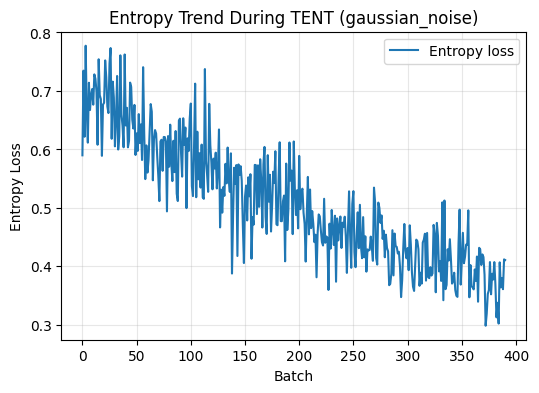

In [ ]:
corruption = ['gaussian_noise']
results_gaussian, ent_gaussian = cifar10_eval(corruption)
plot_entropy_curve(ent_gaussian['gaussian_noise'], 'gaussian_noise')


--- MOTION_BLUR ---


Evaluating on Baseline (motion_blur): 100%|██████████| 391/391 [00:34<00:00, 11.30it/s]


Batch 0: entropy loss = 0.5807
Batch 100: entropy loss = 0.6511
Batch 200: entropy loss = 0.5655
Batch 300: entropy loss = 0.3890


Evaluating on TENT Final (motion_blur): 100%|██████████| 391/391 [00:32<00:00, 11.87it/s]


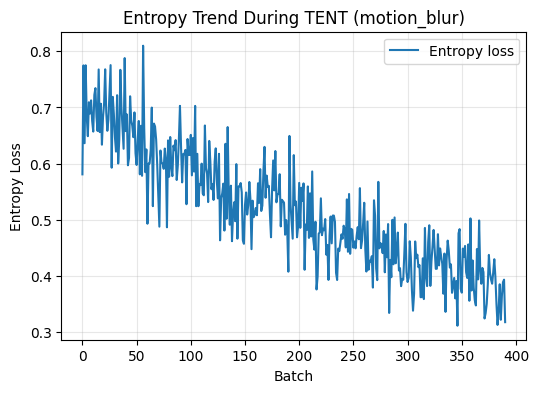

In [ ]:
corruption = ['motion_blur']
results_motion, ent_motion = cifar10_eval(corruption)
plot_entropy_curve(ent_motion['motion_blur'], 'motion_blur')


--- BRIGHTNESS ---


Evaluating on Baseline (brightness): 100%|██████████| 391/391 [00:33<00:00, 11.67it/s]


Batch 0: entropy loss = 0.5701
Batch 100: entropy loss = 0.6371
Batch 200: entropy loss = 0.5353
Batch 300: entropy loss = 0.4107


Evaluating on TENT Final (brightness): 100%|██████████| 391/391 [00:33<00:00, 11.66it/s]


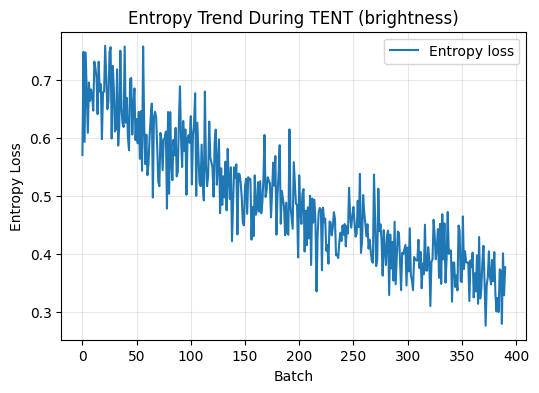

In [ ]:
corruption = ['brightness']
results_brightness, ent_brightness = cifar10_eval(corruption)
plot_entropy_curve(ent_brightness['brightness'], 'brightness')


--- PIXELATE ---


Evaluating on Baseline (pixelate): 100%|██████████| 391/391 [00:33<00:00, 11.50it/s]


Batch 0: entropy loss = 0.5814
Batch 100: entropy loss = 0.6477
Batch 200: entropy loss = 0.5255
Batch 300: entropy loss = 0.3925


Evaluating on TENT Final (pixelate): 100%|██████████| 391/391 [00:35<00:00, 11.16it/s]


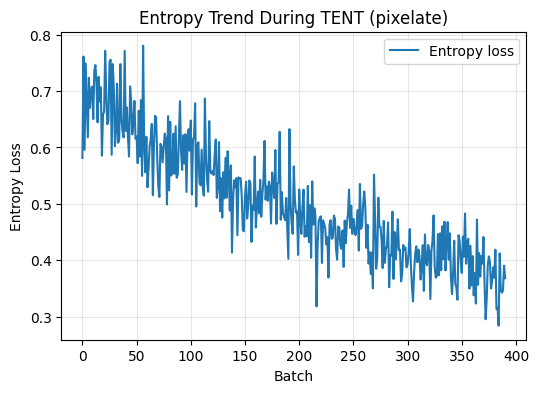

In [ ]:
corruption = ['pixelate']
results_pixelate, ent_pixelate = cifar10_eval(corruption)
plot_entropy_curve(ent_pixelate['pixelate'], 'pixelate')


--- FOG ---


Evaluating on Baseline (fog): 100%|██████████| 391/391 [00:34<00:00, 11.37it/s]


Batch 0: entropy loss = 0.5829
Batch 100: entropy loss = 0.6346
Batch 200: entropy loss = 0.5619
Batch 300: entropy loss = 0.4079


Evaluating on TENT Final (fog): 100%|██████████| 391/391 [00:34<00:00, 11.43it/s]


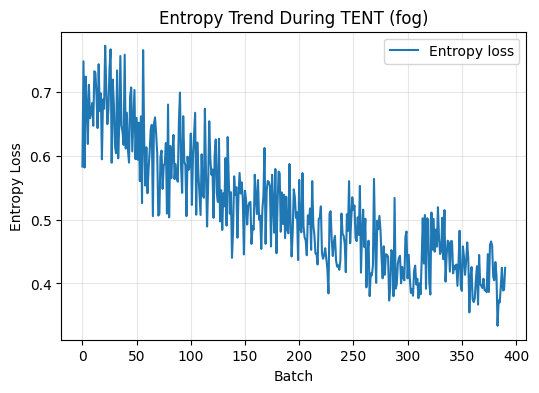

In [ ]:
corruption = ['fog']
results_fog, ent_fog = cifar10_eval(corruption)
plot_entropy_curve(ent_fog['fog'], 'fog')

In [ ]:
# Experiment 2: Sequential corruption using CIFAR-10-C and ResNet18

def plot_sequential_results(all_entropies, all_accuracies, domain_transitions, domain_labels=None, title="Sequential Domain Adaptation"):
    plt.figure(figsize=(9, 5))
    plt.plot(all_entropies, label="Entropy Loss", color="blue")

    num_domains = len(domain_transitions)
    domain_colors = plt.cm.tab10(np.linspace(0, 1, num_domains))
    max_entropy = max(all_entropies) if all_entropies else 1.0

    acc_idx = 0
    for i in range(num_domains):
        color = domain_colors[i]
        label = domain_labels[i] if domain_labels else f"Domain {i+1}"

        # Pre and post adaptation points
        pre_idx, pre_acc = all_accuracies[acc_idx]
        post_idx, post_acc = all_accuracies[acc_idx + 1]
        acc_idx += 2

        plt.scatter(pre_idx, (pre_acc / 100) * max_entropy, color=color, s=50, label=f"{label} (start)")
        plt.text(pre_idx, (pre_acc / 100) * max_entropy + 0.02, f"{pre_acc:.1f}%", fontsize=8, ha='center', color=color)

        plt.scatter(post_idx, (post_acc / 100) * max_entropy, color=color, marker='x', s=60, label=f"{label} (end)")
        plt.text(post_idx, (post_acc / 100) * max_entropy + 0.02, f"{post_acc:.1f}%", fontsize=8, ha='center', color=color)

    # Mark domain transitions
    for i, d in enumerate(domain_transitions[:-1]):
        plt.axvline(d, color="gray", linestyle="--", alpha=0.4)
        if domain_labels:
            plt.text(d, max_entropy * 1.02, f"→ {domain_labels[i+1]}", ha="left", fontsize=8, color="gray")

    plt.title(title)
    plt.xlabel("Batch")
    plt.ylabel("Entropy / Scaled Accuracy")
    plt.legend(fontsize=8)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

def evaluate_sequential_domains(corruption_sequence):
    print("\n=== Sequential Domain Adaptation ===")
    print("Sequence:", " → ".join(corruption_sequence))

    model = load_res18()
    tent_model = prepare_tent_model(model)

    domain_results = {}
    all_entropies = []
    all_accuracies = []
    domain_transitions = []

    for i, corruption in enumerate(corruption_sequence):
        print(f"\n--- Domain {i+1}: {corruption.upper()} ---")
        loader = get_cifar10c_loader(corruption)

        # Accuracy before adapting to this domain
        pre_acc = evaluate_acc(tent_model, loader, f"Pre-adapt ({corruption})")

        # Adaptation for this domain
        entropies = tent_adapt(tent_model, loader, print_every=100)

        # Accuracy after adaptation
        post_acc = evaluate_acc(tent_model, loader, f"Post-adapt ({corruption})")

        domain_results[corruption] = {"pre_acc": pre_acc, "post_acc": post_acc,"entropies": entropies,}

        start_idx = len(all_entropies)
        all_entropies.extend(entropies)

        all_accuracies.append((start_idx, pre_acc))
        all_accuracies.append((len(all_entropies), post_acc))
        domain_transitions.append(len(all_entropies))

    plot_sequential_results(all_entropies, all_accuracies, domain_transitions, domain_labels=corruption_sequence, title="Sequential Domain Adaptation (Entropy & Accuracy)")

    return domain_results


=== Sequential Domain Adaptation ===
Sequence: frost → snow → fog

--- Domain 1: FROST ---


Evaluating on Pre-adapt (frost): 100%|██████████| 391/391 [00:33<00:00, 11.71it/s]


Batch 0: entropy loss = 0.5952
Batch 100: entropy loss = 0.6868
Batch 200: entropy loss = 0.5115
Batch 300: entropy loss = 0.4347


Evaluating on Post-adapt (frost): 100%|██████████| 391/391 [00:33<00:00, 11.77it/s]



--- Domain 2: SNOW ---


...

Evaluating on Post-adapt (snow): 100%|██████████| 391/391 [00:35<00:00, 11.06it/s]



--- Domain 3: FOG ---


Evaluating on Pre-adapt (fog): 100%|██████████| 391/391 [00:35<00:00, 11.14it/s]


Batch 0: entropy loss = 0.2389
Batch 100: entropy loss = 0.2779
Batch 200: entropy loss = 0.3527
Batch 300: entropy loss = 0.3127


Evaluating on Post-adapt (fog): 100%|██████████| 391/391 [00:35<00:00, 11.10it/s]


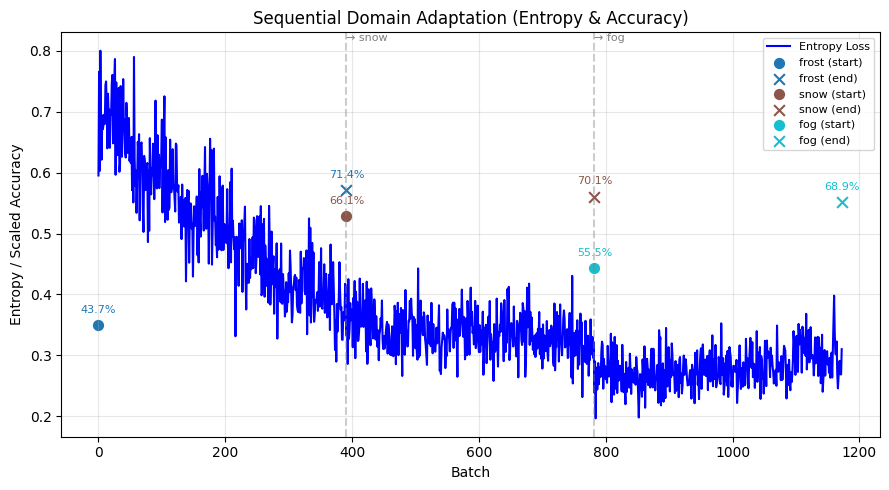

In [75]:
# Example 1: Winter Conditions: frost -> snow -> fog
seq_weather = ["frost", "snow", "fog"]
results_seq1 = evaluate_sequential_domains(seq_weather)


=== Sequential Domain Adaptation ===
Sequence: brightness → fog → spatter

--- Domain 1: BRIGHTNESS ---


Evaluating on Pre-adapt (brightness): 100%|██████████| 391/391 [00:33<00:00, 11.54it/s]


Batch 0: entropy loss = 0.5701
Batch 100: entropy loss = 0.6371
Batch 200: entropy loss = 0.5353
Batch 300: entropy loss = 0.4107


Evaluating on Post-adapt (brightness): 100%|██████████| 391/391 [00:33<00:00, 11.63it/s]



--- Domain 2: FOG ---


...

Evaluating on Post-adapt (fog): 100%|██████████| 391/391 [00:33<00:00, 11.60it/s]



--- Domain 3: SPATTER ---


Evaluating on Pre-adapt (spatter): 100%|██████████| 391/391 [00:35<00:00, 11.15it/s]


Batch 0: entropy loss = 0.2514
Batch 100: entropy loss = 0.3403
Batch 200: entropy loss = 0.3592
Batch 300: entropy loss = 0.3108


Evaluating on Post-adapt (spatter): 100%|██████████| 391/391 [00:34<00:00, 11.34it/s]


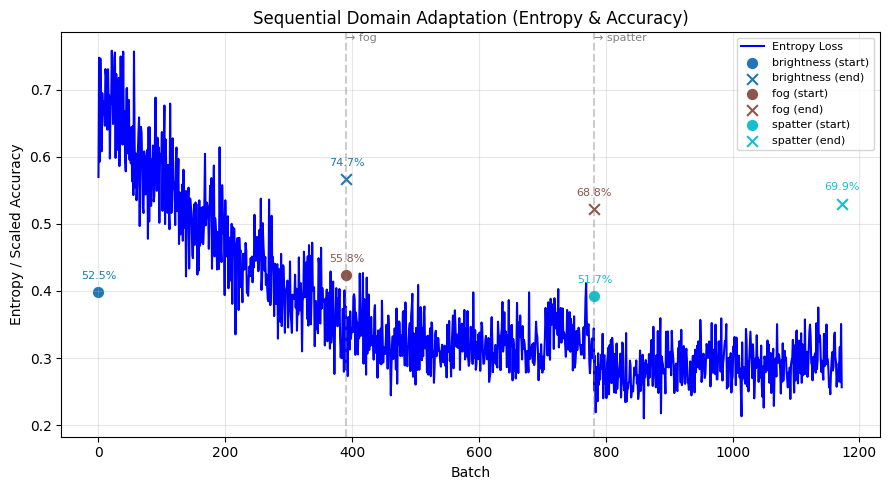

In [76]:
# Example 2: Rainy weather: brightness -> fog -> spatter
# brightness: simulates cloudy/dim lighting
# fog: adds low visibility haze
# spatter: represents rain on the lens
seq_weather2 = ["brightness", "fog", "spatter"]
results_seq2 = evaluate_sequential_domains(seq_weather2)


=== Sequential Domain Adaptation ===
Sequence: defocus_blur → gaussian_noise → jpeg_compression

--- Domain 1: DEFOCUS_BLUR ---


Evaluating on Pre-adapt (defocus_blur): 100%|██████████| 391/391 [00:34<00:00, 11.41it/s]


Batch 0: entropy loss = 0.5767
Batch 100: entropy loss = 0.6509
Batch 200: entropy loss = 0.5286
Batch 300: entropy loss = 0.3880


Evaluating on Post-adapt (defocus_blur): 100%|██████████| 391/391 [00:33<00:00, 11.55it/s]



--- Domain 2: GAUSSIAN_NOISE ---


...

Evaluating on Post-adapt (gaussian_noise): 100%|██████████| 391/391 [00:33<00:00, 11.61it/s]



--- Domain 3: JPEG_COMPRESSION ---


Evaluating on Pre-adapt (jpeg_compression): 100%|██████████| 391/391 [00:33<00:00, 11.70it/s]


Batch 0: entropy loss = 0.2552
Batch 100: entropy loss = 0.2955
Batch 200: entropy loss = 0.3389
Batch 300: entropy loss = 0.2503


Evaluating on Post-adapt (jpeg_compression): 100%|██████████| 391/391 [00:35<00:00, 10.95it/s]


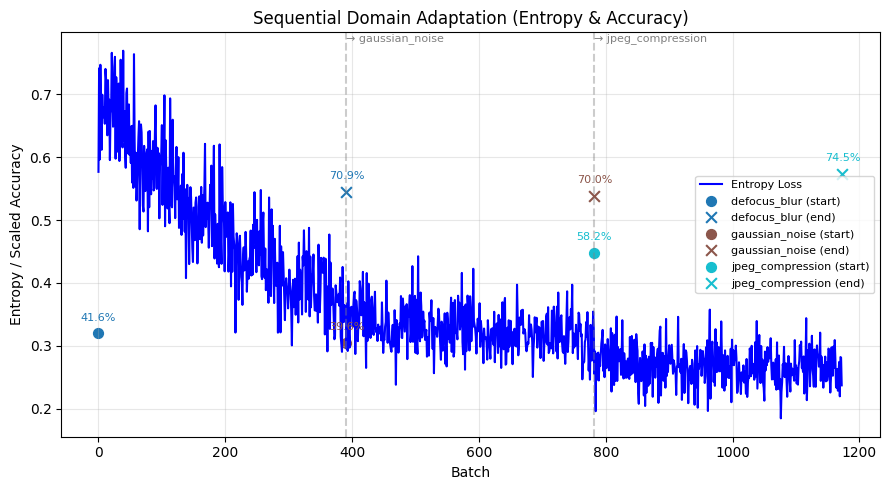

In [77]:
# Example 3: Camera degradation: defocus_blur -> gaussian_noise -> jpeg_compression
# defocus_blur: lens loses sharpness
# gaussian_noise: sensor begins introducing noise
# jpeg_compression: image quality degrades
seq_camera = ["defocus_blur", "gaussian_noise", "jpeg_compression"]
results_seq3 = evaluate_sequential_domains(seq_camera)

In [ ]:
# DATASET 2: CIFAR-100-C

In [34]:
def get_cifar100c_loader(root, corruption, batch_size=128, num_workers=0):
    x = np.load(f"{root}/{corruption}.npy")
    y = np.load(f"{root}/labels.npy")
    x = torch.tensor(x).permute(0, 3, 1, 2).float() / 255.0
    y = torch.tensor(y).long()

    dataset = TensorDataset(x, y)
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=True, num_workers=num_workers)

    return loader

def tent_adapt_ablate(model, loader, max_steps= 301, eval_steps=None):
    if eval_steps is None:
        eval_steps = [5, 10, 20, 40, 80, 160, 300]

    model.train()
    optimizer = torch.optim.SGD(  [p for p in model.parameters() if p.requires_grad], lr=1e-3, momentum=0.9)

    entropy_history = []
    acc_at_steps = {}

    for step, (x, _) in enumerate(loader):
        if step >= max_steps:
            break

        optimizer.zero_grad()
        logits = model(x)
        probs = F.softmax(logits, dim=1)
        entropy = -(probs * probs.log()).sum(1).mean()
        entropy.backward()
        optimizer.step()

        entropy_history.append(entropy.item())

        # Evaluate accuracy at selected steps 
        if step in eval_steps:
            acc = evaluate_acc(model, loader, max_steps=1000)
            acc_at_steps[step] = acc
            model.train()
            print(f"[Ablate] Step: {step}. Entropy = {entropy.item():.4f}. Accuracy: {acc:.2f}")

    return entropy_history, acc_at_steps


In [ ]:
# Experiment 3: Single corruption using CIFAR-100-C and ResNet18

C:\Users\dgulv\AppData\Local\Temp\ipykernel_6660\4169254153.py:7: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state_dict = torch.load(checkpoint_path)


Loaded CIFAR- 100  weights from  cifar100_baseline.pth


Evaluating on test: 100%|██████████| 391/391 [00:31<00:00, 12.33it/s]


Baseline accuracy: 33.802
[TENT] Step 0: entropy=1.8527
[TENT] Step 20: entropy=1.7107
[TENT] Step 40: entropy=1.6925
[TENT] Step 60: entropy=1.6366
[TENT] Step 80: entropy=1.5206
[TENT] Step 100: entropy=1.6090
[TENT] Step 120: entropy=1.5597
[TENT] Step 140: entropy=1.5561
[TENT] Step 160: entropy=1.6196
[TENT] Step 180: entropy=1.5509
[TENT] Step 200: entropy=1.6199


Evaluating on test: 100%|██████████| 391/391 [00:32<00:00, 12.21it/s]


Post-TENT accuracy: 47.192


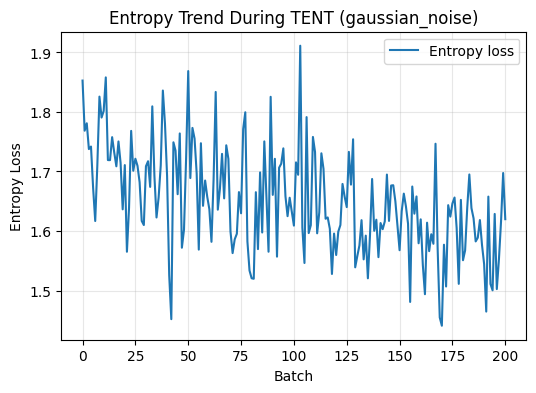

In [55]:
loader1 = get_cifar100c_loader(root="cifar100c", corruption="gaussian_noise", batch_size=128)

model1 = load_res18(classes=100, checkpoint_path="cifar100_baseline.pth")
model1 = prepare_tent_model(model1)

baseline_acc1 = evaluate_acc(model1, loader1, max_steps=1000)
print("Baseline accuracy:", baseline_acc1)

entropy_history1 = tent_adapt(model1, loader1, max_steps=201)

post_acc1 = evaluate_acc(model1, loader1, max_steps=1000)
print("Post-TENT accuracy:", post_acc1)

plot_entropy_curve(entropy_history1, "gaussian_noise")

C:\Users\dgulv\AppData\Local\Temp\ipykernel_6660\4169254153.py:7: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state_dict = torch.load(checkpoint_path)


Loaded CIFAR- 100  weights from  cifar100_baseline.pth


Evaluating on test: 100%|██████████| 391/391 [00:31<00:00, 12.46it/s]


Baseline accuracy: 33.802


Evaluating on test: 100%|██████████| 391/391 [00:30<00:00, 12.75it/s]


...

[Ablate] Step: 80. Entropy = 1.6407. Accuracy: 46.36


Evaluating on test: 100%|██████████| 391/391 [00:30<00:00, 12.78it/s]


[Ablate] Step: 160. Entropy = 1.5875. Accuracy: 47.14


Evaluating on test: 100%|██████████| 391/391 [00:30<00:00, 12.75it/s]


[Ablate] Step: 300. Entropy = 1.6437. Accuracy: 47.67
Accuracies during TENT: {5: 41.952, 10: 44.854, 20: 45.86, 40: 45.938, 80: 46.364, 160: 47.136, 300: 47.672}


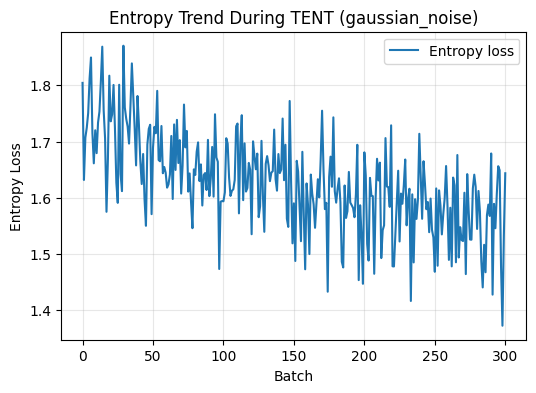

In [37]:
# Experiment 3.1: Step Ablation, gaussian noise

loader1 = get_cifar100c_loader(root="cifar100c", corruption="gaussian_noise", batch_size=128)
model1 = load_res18(classes=100, checkpoint_path="cifar100_baseline.pth")
model1 = prepare_tent_model(model1)

baseline_acc1 = evaluate_acc(model1, loader1, max_steps=1000)
print("Baseline accuracy:", baseline_acc1)

entropy_hist1a, acc_logs1a = tent_adapt_ablate(model=model1, loader=loader1, eval_steps=[5, 10, 20, 40, 80, 160, 300])

print("Accuracies during TENT:", acc_logs1a)
plot_entropy_curve(entropy_hist1a, corruption_name="gaussian_noise")


C:\Users\dgulv\AppData\Local\Temp\ipykernel_6660\4169254153.py:7: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state_dict = torch.load(checkpoint_path)


Loaded CIFAR- 100  weights from  cifar100_baseline.pth


Evaluating on test: 100%|██████████| 391/391 [00:29<00:00, 13.25it/s]


Baseline accuracy: 39.098
[TENT] Step 0: entropy=1.7436
[TENT] Step 20: entropy=1.6206
[TENT] Step 40: entropy=1.6469
[TENT] Step 60: entropy=1.6487
[TENT] Step 80: entropy=1.6035
[TENT] Step 100: entropy=1.5583
[TENT] Step 120: entropy=1.4812
[TENT] Step 140: entropy=1.5707
[TENT] Step 160: entropy=1.5067
[TENT] Step 180: entropy=1.7834
[TENT] Step 200: entropy=1.4895


Evaluating on test: 100%|██████████| 391/391 [00:29<00:00, 13.08it/s]


Post-TENT accuracy: 50.26


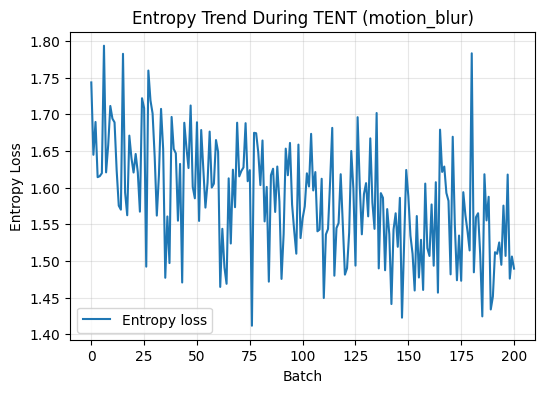

In [54]:
loader2 = get_cifar100c_loader(root="cifar100c", corruption="motion_blur", batch_size=128)

model2 = load_res18(classes=100, checkpoint_path="cifar100_baseline.pth")
model2 = prepare_tent_model(model2)

baseline_acc2 = evaluate_acc(model2, loader2, max_steps=1000)
print("Baseline accuracy:", baseline_acc2)

entropy_history2 = tent_adapt(model2, loader2, max_steps=201)

post_acc2 = evaluate_acc(model2, loader2, max_steps=1000)
print("Post-TENT accuracy:", post_acc2)

plot_entropy_curve(entropy_history2, "motion_blur")

C:\Users\dgulv\AppData\Local\Temp\ipykernel_6660\4169254153.py:7: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state_dict = torch.load(checkpoint_path)


Loaded CIFAR- 100  weights from  cifar100_baseline.pth


Evaluating on test: 100%|██████████| 391/391 [00:31<00:00, 12.42it/s]


Baseline accuracy: 39.098


Evaluating on test: 100%|██████████| 391/391 [00:31<00:00, 12.41it/s]


...

[Ablate] Step: 80. Entropy = 1.5376. Accuracy: 49.83


Evaluating on test: 100%|██████████| 391/391 [00:31<00:00, 12.36it/s]


[Ablate] Step: 160. Entropy = 1.5669. Accuracy: 50.35


Evaluating on test: 100%|██████████| 391/391 [00:31<00:00, 12.47it/s]


[Ablate] Step: 300. Entropy = 1.4218. Accuracy: 50.37
Accuracies during TENT: {5: 44.462, 10: 47.082, 20: 49.216, 40: 49.662, 80: 49.828, 160: 50.352, 300: 50.366}


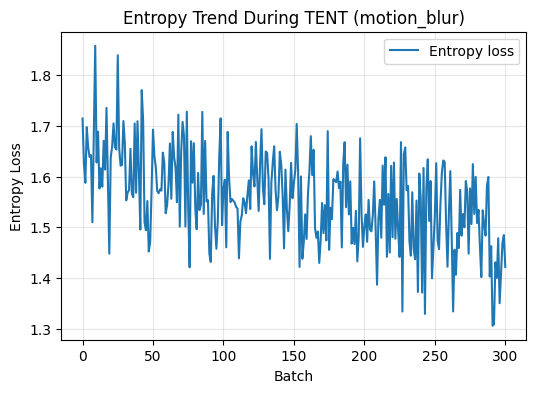

In [39]:
# Experiment 3.2: Step Ablation, motion blur

loader2 = get_cifar100c_loader(root="cifar100c", corruption="motion_blur", batch_size=128)
model2 = load_res18(classes=100, checkpoint_path="cifar100_baseline.pth")
model2 = prepare_tent_model(model2)

baseline_acc2 = evaluate_acc(model2, loader2, max_steps=1000)
print("Baseline accuracy:", baseline_acc2)

entropy_hist2a, acc_logs2a = tent_adapt_ablate(model=model2, loader=loader2, eval_steps=[5, 10, 20, 40, 80, 160, 300])

print("Accuracies during TENT:", acc_logs2a)
plot_entropy_curve(entropy_hist2a, corruption_name="motion_blur")


C:\Users\dgulv\AppData\Local\Temp\ipykernel_6660\4169254153.py:7: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state_dict = torch.load(checkpoint_path)


Loaded CIFAR- 100  weights from  cifar100_baseline.pth


Evaluating on test: 100%|██████████| 391/391 [00:30<00:00, 12.69it/s]


Baseline accuracy: 51.25
[TENT] Step 0: entropy=1.5236
[TENT] Step 20: entropy=1.6656
[TENT] Step 40: entropy=1.5075
[TENT] Step 60: entropy=1.5414
[TENT] Step 80: entropy=1.5882
[TENT] Step 100: entropy=1.6385
[TENT] Step 120: entropy=1.4941
[TENT] Step 140: entropy=1.4747
[TENT] Step 160: entropy=1.3787
[TENT] Step 180: entropy=1.3943
[TENT] Step 200: entropy=1.5591


Evaluating on test: 100%|██████████| 391/391 [00:30<00:00, 12.97it/s]


Post-TENT accuracy: 53.486


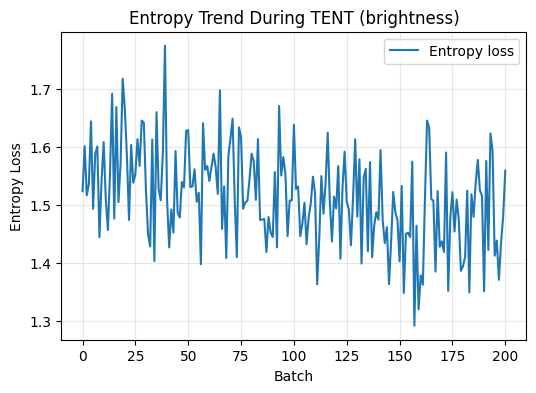

In [53]:
loader3 = get_cifar100c_loader(root="cifar100c", corruption="brightness", batch_size=128)

model3 = load_res18(classes=100, checkpoint_path="cifar100_baseline.pth")
model3 = prepare_tent_model(model3)

baseline_acc3 = evaluate_acc(model3, loader3, max_steps=1000)
print("Baseline accuracy:", baseline_acc3)

entropy_history3 = tent_adapt(model3, loader3, max_steps=201)

post_acc3 = evaluate_acc(model3, loader3, max_steps=1000)
print("Post-TENT accuracy:", post_acc3)

plot_entropy_curve(entropy_history3, "brightness")

C:\Users\dgulv\AppData\Local\Temp\ipykernel_6660\4169254153.py:7: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state_dict = torch.load(checkpoint_path)


Loaded CIFAR- 100  weights from  cifar100_baseline.pth


Evaluating on test: 100%|██████████| 391/391 [00:30<00:00, 13.03it/s]


Baseline accuracy: 50.3
[TENT] Step 0: entropy=1.6423
[TENT] Step 20: entropy=1.5463
[TENT] Step 40: entropy=1.5164
[TENT] Step 60: entropy=1.7020
[TENT] Step 80: entropy=1.6322
[TENT] Step 100: entropy=1.5271
[TENT] Step 120: entropy=1.4142
[TENT] Step 140: entropy=1.4356
[TENT] Step 160: entropy=1.4364
[TENT] Step 180: entropy=1.5379
[TENT] Step 200: entropy=1.5339


Evaluating on test: 100%|██████████| 391/391 [00:29<00:00, 13.05it/s]


Post-TENT accuracy: 52.324


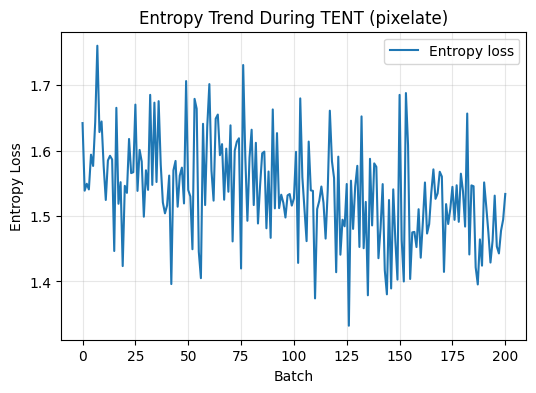

In [51]:
loader4 = get_cifar100c_loader(root="cifar100c", corruption="pixelate", batch_size=128)

model4 = load_res18(classes=100, checkpoint_path="cifar100_baseline.pth")
model4 = prepare_tent_model(model4)

baseline_acc4 = evaluate_acc(model4, loader4, max_steps=1000)
print("Baseline accuracy:", baseline_acc4)

entropy_history4 = tent_adapt(model4, loader4, max_steps=201)

post_acc4 = evaluate_acc(model4, loader4, max_steps=1000)
print("Post-TENT accuracy:", post_acc4)

plot_entropy_curve(entropy_history4, "pixelate")

C:\Users\dgulv\AppData\Local\Temp\ipykernel_6660\4169254153.py:7: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state_dict = torch.load(checkpoint_path)


Loaded CIFAR- 100  weights from  cifar100_baseline.pth


Evaluating on test: 100%|██████████| 391/391 [00:29<00:00, 13.20it/s]


Baseline accuracy: 36.888
[TENT] Step 0: entropy=1.6515
[TENT] Step 20: entropy=1.6893
[TENT] Step 40: entropy=1.6396
[TENT] Step 60: entropy=1.5883
[TENT] Step 80: entropy=1.6662
[TENT] Step 100: entropy=1.5998
[TENT] Step 120: entropy=1.6354
[TENT] Step 140: entropy=1.6407


Evaluating on test: 100%|██████████| 391/391 [00:30<00:00, 12.84it/s]


Post-TENT accuracy: 46.166


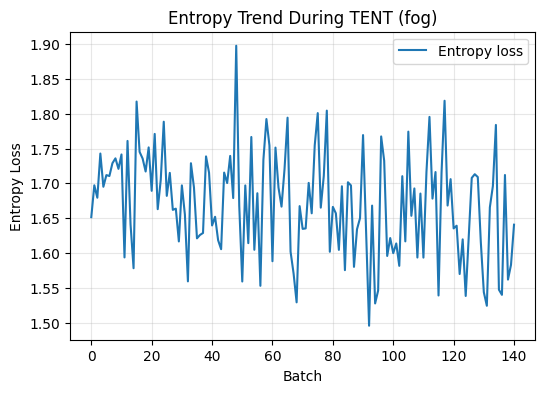

In [52]:
loader5 = get_cifar100c_loader(root="cifar100c", corruption="fog", batch_size=128)

model5 = load_res18(classes=100, checkpoint_path="cifar100_baseline.pth")
model5 = prepare_tent_model(model5)

baseline_acc5 = evaluate_acc(model5, loader5, max_steps=1000)
print("Baseline accuracy:", baseline_acc5)

entropy_history5 = tent_adapt(model5, loader5, max_steps=141)

post_acc5 = evaluate_acc(model5, loader5, max_steps=1000)
print("Post-TENT accuracy:", post_acc5)

plot_entropy_curve(entropy_history5, "fog")

C:\Users\dgulv\AppData\Local\Temp\ipykernel_6660\4169254153.py:7: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state_dict = torch.load(checkpoint_path)


Loaded CIFAR- 100  weights from  cifar100_baseline.pth


Evaluating on test: 100%|██████████| 391/391 [00:30<00:00, 12.68it/s]


Baseline accuracy: 33.802


Evaluating on test: 100%|██████████| 391/391 [00:41<00:00,  9.34it/s]


...

[Ablate] Step: 80. Entropy = 1.6286. Accuracy: 47.79


Evaluating on test: 100%|██████████| 391/391 [00:32<00:00, 11.96it/s]


[Ablate] Step: 160. Entropy = 1.4770. Accuracy: 47.69


Evaluating on test: 100%|██████████| 391/391 [00:31<00:00, 12.32it/s]


[Ablate] Step: 300. Entropy = 1.3623. Accuracy: 47.54
Accuracies during TENT: {5: 47.484, 10: 47.592, 20: 47.588, 40: 47.694, 80: 47.788, 160: 47.686, 300: 47.542}


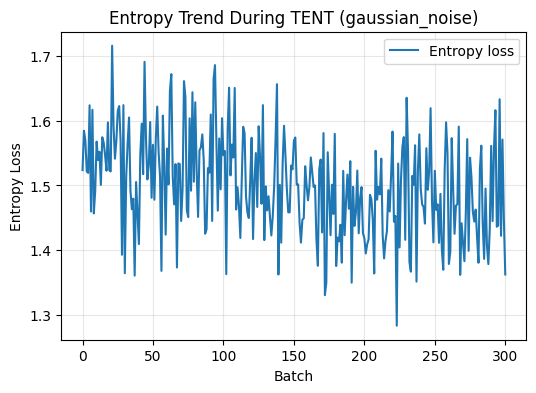

In [ ]:
# Experiment 3.5: Step Ablation, fog

loader5 = get_cifar100c_loader(root="cifar100c", corruption="gaussian_noise", batch_size=128)
model5 = load_res18(classes=100, checkpoint_path="cifar100_baseline.pth")
model5 = prepare_tent_model(model5)

baseline_acc5 = evaluate_acc(model5, loader5, max_steps=1000)
print("Baseline accuracy:", baseline_acc5)

entropy_hist5a, acc_logs5a = tent_adapt_ablate(model=model1, loader=loader1, eval_steps=[5, 10, 20, 40, 80, 160, 300])

print("Accuracies during TENT:", acc_logs5a)
plot_entropy_curve(entropy_hist5a, corruption_name="fog")


C:\Users\dgulv\AppData\Local\Temp\ipykernel_6660\4169254153.py:7: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state_dict = torch.load(checkpoint_path)


Loaded CIFAR- 100  weights from  cifar100_baseline.pth


Evaluating on test: 100%|██████████| 391/391 [00:32<00:00, 12.03it/s]


Baseline accuracy: 41.408
[TENT] Step 0: entropy=1.6445
[TENT] Step 20: entropy=1.6806
[TENT] Step 40: entropy=1.7154
[TENT] Step 60: entropy=1.6976
[TENT] Step 80: entropy=1.6469
[TENT] Step 100: entropy=1.4569
[TENT] Step 120: entropy=1.6524
[TENT] Step 140: entropy=1.7021
[TENT] Step 160: entropy=1.6561
[TENT] Step 180: entropy=1.5647
[TENT] Step 200: entropy=1.5903


Evaluating on test: 100%|██████████| 391/391 [00:31<00:00, 12.36it/s]


Post-TENT accuracy: 48.352


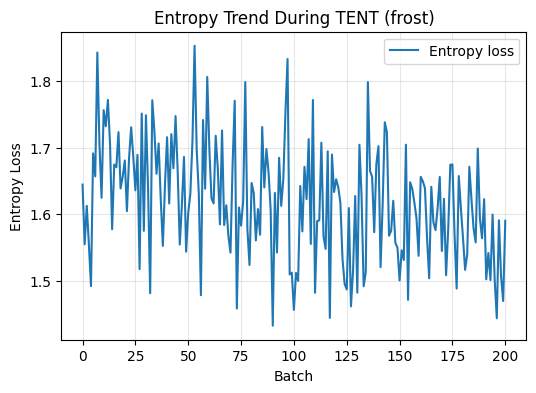

In [56]:
loader6 = get_cifar100c_loader(root="cifar100c", corruption="frost", batch_size=128)

model6 = load_res18(classes=100, checkpoint_path="cifar100_baseline.pth")
model6 = prepare_tent_model(model6)

baseline_acc6 = evaluate_acc(model6, loader6, max_steps=1000)
print("Baseline accuracy:", baseline_acc6)

entropy_history6 = tent_adapt(model6, loader6, max_steps=201)

post_acc6 = evaluate_acc(model6, loader6, max_steps=1000)
print("Post-TENT accuracy:", post_acc6)

plot_entropy_curve(entropy_history6, "frost")

C:\Users\dgulv\AppData\Local\Temp\ipykernel_6660\4169254153.py:7: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state_dict = torch.load(checkpoint_path)


Loaded CIFAR- 100  weights from  cifar100_baseline.pth


Evaluating on test: 100%|██████████| 391/391 [00:31<00:00, 12.48it/s]


Baseline accuracy: 40.386
[TENT] Step 0: entropy=1.7627
[TENT] Step 20: entropy=1.6021
[TENT] Step 40: entropy=1.6076
[TENT] Step 60: entropy=1.6981
[TENT] Step 80: entropy=1.6258
[TENT] Step 100: entropy=1.5066
[TENT] Step 120: entropy=1.6681
[TENT] Step 140: entropy=1.5923
[TENT] Step 160: entropy=1.6177
[TENT] Step 180: entropy=1.5665
[TENT] Step 200: entropy=1.6042


Evaluating on test: 100%|██████████| 391/391 [00:32<00:00, 11.99it/s]


Post-TENT accuracy: 46.436


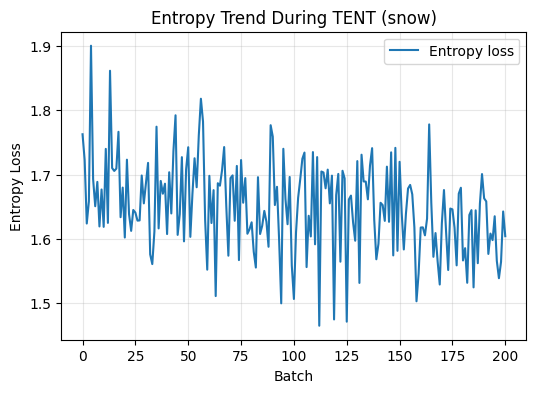

In [57]:
loader7 = get_cifar100c_loader(root="cifar100c", corruption="snow", batch_size=128)

model7 = load_res18(classes=100, checkpoint_path="cifar100_baseline.pth")
model7 = prepare_tent_model(model7)

baseline_acc7 = evaluate_acc(model7, loader7, max_steps=1000)
print("Baseline accuracy:", baseline_acc7)

entropy_history7 = tent_adapt(model7, loader7, max_steps=201)

post_acc7 = evaluate_acc(model7, loader7, max_steps=1000)
print("Post-TENT accuracy:", post_acc7)

plot_entropy_curve(entropy_history7, "snow")

In [ ]:
# Experiment 4: Sequential domains using CIFAR-100-C

In [ ]:
def evaluate_sequential_domains_cifar100(corruption_sequence, batch_size=128):
    print("\n=== CIFAR-100 Sequential Domain Adaptation ===")
    print("Sequence:", " → ".join(corruption_sequence))

    tent_model = load_res18(classes=100, checkpoint_path="cifar100_baseline.pth")
    tent_model = prepare_tent_model(tent_model)

    domain_results = {}
    all_entropies = []
    all_accuracies = []
    domain_transitions = []

    for i, corruption in enumerate(corruption_sequence):
        print(f"\n--- Domain {i+1}: {corruption.upper()} ---")

        loader = get_cifar100c_loader(root="cifar100c", corruption=corruption, batch_size=batch_size)

        # Pre-adaptation accuracy
        pre_acc = evaluate_acc(tent_model, loader, max_steps=1000)
        print("Pre-tent accuracy: ", pre_acc)

        # Sequential TENT adaptation
        entropies = tent_adapt(tent_model, loader, max_steps=201, print_every=25)

        # Post adaptation accuracy
        post_acc = evaluate_acc(tent_model, loader, max_steps=1000)
        print("Post-tent accuracy: ", post_acc)

        domain_results[corruption] = {"pre_acc": pre_acc, "post_acc": post_acc, "entropies": entropies}

        start_idx = len(all_entropies)
        all_entropies.extend(entropies)
        all_accuracies.append((start_idx, pre_acc))
        all_accuracies.append((len(all_entropies), post_acc))
        domain_transitions.append(len(all_entropies))

    plot_sequential_results(all_entropies, all_accuracies, domain_transitions, domain_labels=corruption_sequence, title="CIFAR-100 Sequential Domain Adaptation")

    return domain_results


=== CIFAR-100 Sequential Domain Adaptation ===
Sequence: frost → snow → fog


C:\Users\dgulv\AppData\Local\Temp\ipykernel_11828\399575643.py:11: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state_dict = torch.load(checkpoint_path, map_location=device

Loaded CIFAR-100 weights from cifar100_baseline.pth

--- Domain 1: FROST ---
Pre-tent accuracy:  41.408
[TENT] Step 0: entropy=1.6882
[TENT] Step 25: entropy=1.7323
[TENT] Step 50: entropy=1.5017
[TENT] Step 75: entropy=1.6202
[TENT] Step 100: entropy=1.4850
[TENT] Step 125: entropy=1.5888
[TENT] Step 150: entropy=1.4174
[TENT] Step 175: entropy=1.4520
[TENT] Step 200: entropy=1.4436
Post-tent accuracy:  47.446

--- Domain 2: SNOW ---
Pre-tent accuracy:  41.792
[TENT] Step 0: entropy=1.3574
[TENT] Step 25: entropy=1.4348
[TENT] Step 50: entropy=1.2756
[TENT] Step 75: entropy=1.2892
[TENT] Step 100: entropy=1.3995
[TENT] Step 125: entropy=1.1907
[TENT] Step 150: entropy=1.2108
[TENT] Step 175: entropy=1.2413
[TENT] Step 200: entropy=1.1431
Post-tent accuracy:  42.79

--- Domain 3: FOG ---
Pre-tent accuracy:  30.342000000000002
[TENT] Step 0: entropy=1.1559
[TENT] Step 25: entropy=1.1610
[TENT] Step 50: entropy=0.9272
[TENT] Step 75: entropy=1.0525
[TENT] Step 100: entropy=0.8915
[TENT] 

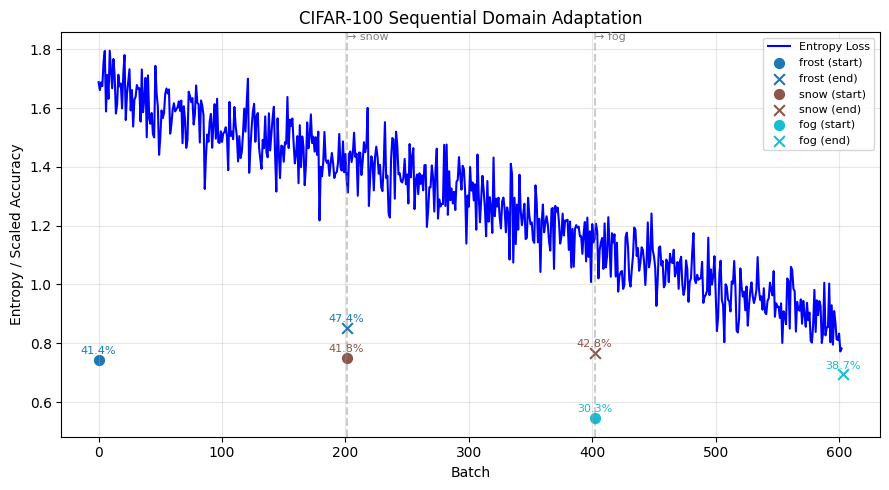

In [ ]:
# Winter weather
corruptions100a = ["frost", "snow", "fog"]
results_100 = evaluate_sequential_domains_cifar100(corruption_sequence=corruptions100a, batch_size=128)



=== CIFAR-100 Sequential Domain Adaptation ===
Sequence: brightness → fog → spatter


C:\Users\dgulv\AppData\Local\Temp\ipykernel_11828\399575643.py:11: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state_dict = torch.load(checkpoint_path, map_location=device

Loaded CIFAR-100 weights from cifar100_baseline.pth

--- Domain 1: BRIGHTNESS ---
Pre-tent accuracy:  51.24999999999999
[TENT] Step 0: entropy=1.6246
[TENT] Step 25: entropy=1.5132
[TENT] Step 50: entropy=1.5316
[TENT] Step 75: entropy=1.4204
[TENT] Step 100: entropy=1.3108
[TENT] Step 125: entropy=1.3531
[TENT] Step 150: entropy=1.2466
[TENT] Step 175: entropy=1.3507
[TENT] Step 200: entropy=1.3669
Post-tent accuracy:  52.583999999999996

--- Domain 2: FOG ---
Pre-tent accuracy:  34.296
[TENT] Step 0: entropy=1.4940
[TENT] Step 25: entropy=1.4440
[TENT] Step 50: entropy=1.3769
[TENT] Step 75: entropy=1.3011
[TENT] Step 100: entropy=1.3572
[TENT] Step 125: entropy=1.1865
[TENT] Step 150: entropy=1.2145
[TENT] Step 175: entropy=1.2510
[TENT] Step 200: entropy=1.1635
Post-tent accuracy:  42.52

--- Domain 3: SPATTER ---
Pre-tent accuracy:  32.808
[TENT] Step 0: entropy=1.1157
[TENT] Step 25: entropy=1.0800
[TENT] Step 50: entropy=1.0097
[TENT] Step 75: entropy=0.9151
[TENT] Step 100: ent

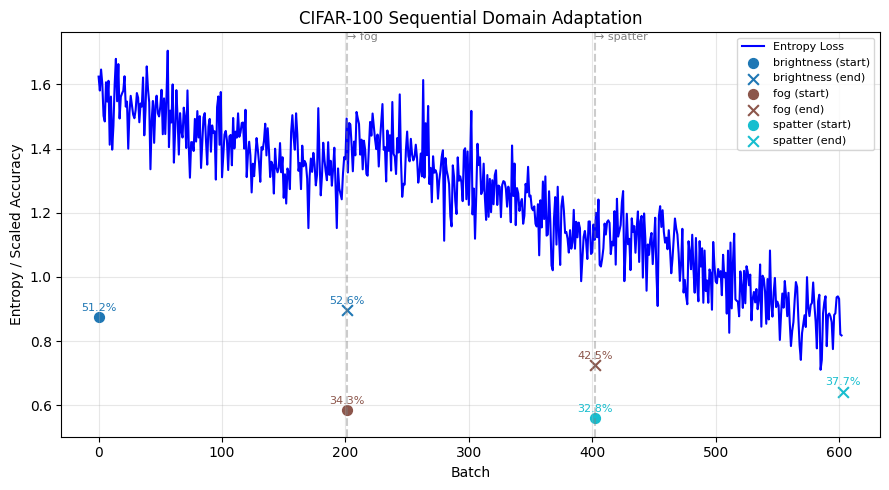

In [ ]:
# Rainy weather
corruptions100b = ["brightness", "fog", "spatter"]
results_100b = evaluate_sequential_domains_cifar100(corruption_sequence=corruptions100b,batch_size=128)



=== CIFAR-100 Sequential Domain Adaptation ===
Sequence: defocus_blur → gaussian_noise → jpeg_compression


C:\Users\dgulv\AppData\Local\Temp\ipykernel_11828\399575643.py:11: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state_dict = torch.load(checkpoint_path, map_location=device

Loaded CIFAR-100 weights from cifar100_baseline.pth

--- Domain 1: DEFOCUS_BLUR ---
Pre-tent accuracy:  44.916
[TENT] Step 0: entropy=1.4781
[TENT] Step 25: entropy=1.5585
[TENT] Step 50: entropy=1.4508
[TENT] Step 75: entropy=1.5372
[TENT] Step 100: entropy=1.4623
[TENT] Step 125: entropy=1.4993
[TENT] Step 150: entropy=1.4443
[TENT] Step 175: entropy=1.3120
[TENT] Step 200: entropy=1.2271
Post-tent accuracy:  50.808

--- Domain 2: GAUSSIAN_NOISE ---
Pre-tent accuracy:  27.21
[TENT] Step 0: entropy=1.4814
[TENT] Step 25: entropy=1.4001
[TENT] Step 50: entropy=1.5735
[TENT] Step 75: entropy=1.2097
[TENT] Step 100: entropy=1.2407
[TENT] Step 125: entropy=1.4182
[TENT] Step 150: entropy=1.1609
[TENT] Step 175: entropy=1.1707
[TENT] Step 200: entropy=1.1159
Post-tent accuracy:  43.046

--- Domain 3: JPEG_COMPRESSION ---
Pre-tent accuracy:  35.093999999999994
[TENT] Step 0: entropy=1.2075
[TENT] Step 25: entropy=1.0013
[TENT] Step 50: entropy=1.0222
[TENT] Step 75: entropy=0.8636
[TENT] St

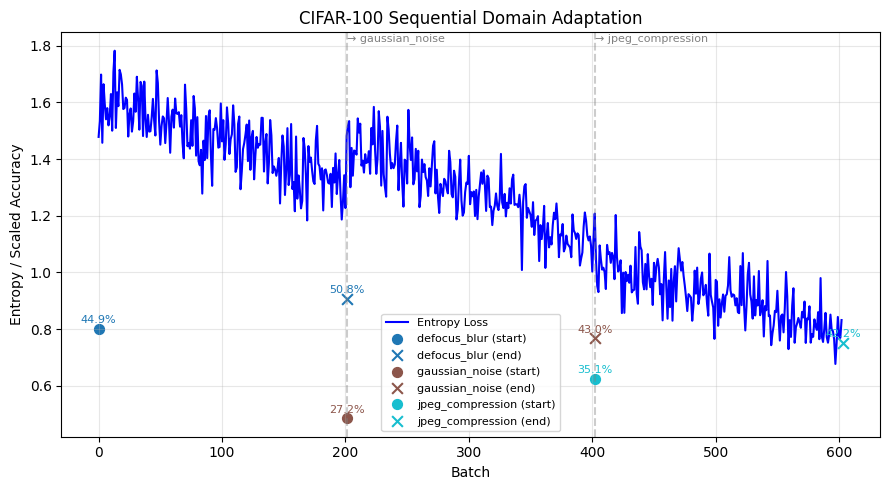

In [ ]:
# Camera degradation
corruptions100c = ["defocus_blur", "gaussian_noise", "jpeg_compression"]
results_100c = evaluate_sequential_domains_cifar100(corruption_sequence=corruptions100c, batch_size=128)


In [ ]:
# DATASET 3: ImageNet-C

In [4]:
IMAGENET_C_PATH = "imagenet_c"  

AVAILABLE_IMAGENETC = {"gaussian_noise": "gaussian_noise","shot_noise": "shot_noise","impulse_noise": "impulse_noise", 
                       "glass_blur": "glass_blur", "defocus_blur": "defocus_blur", "motion_blur": "motion_blur","zoom_blur": "zoom_blur", 
                       "fog":"fog", "snow":"snow", "brightness":"brightness", "frost":"frost"}

def get_imagenet_c_loader(corruption, severity=3, batch_size=64):
    path = os.path.join(IMAGENET_C_PATH, AVAILABLE_IMAGENETC[corruption],str(severity))
    transform = transforms.Compose([transforms.Resize(256), transforms.CenterCrop(224), transforms.ToTensor(),])
    dataset = torchvision.datasets.ImageFolder(path, transform=transform)
    loader = torch.utils.data.DataLoader(dataset, batch_size=batch_size, shuffle=True)
    return loader

def load_res50():
    model = timm.create_model("resnet50", pretrained=True)
    model.train()
    return model

In [44]:
# Experiment 5: Single corruptions using ImageNet-C and ResNet50

def imagenet_eval(corruption, severity=3, steps=201):

    print(f"\n=== ImageNet-C Experiment: {corruption} (severity {severity}) ===")

    # Load ResNet50 ImageNet model
    model = load_res50()
    model.eval()

    # Load corrupted ImageNet-C
    loader = get_imagenet_c_loader(corruption, severity, batch_size=64)

    # Baseline (16 batches of size 64)
    base_acc = evaluate_acc(model, loader, f"Baseline ({corruption})", max_steps=16)
    
    tent_model = prepare_tent_model(model)
    # Adaptation
    entropies = tent_adapt(tent_model, loader, max_steps=steps)

    # After TENT (16 batches of size 64)
    tent_model.eval()
    tent_acc = evaluate_acc(tent_model, loader, f"TENT Final ({corruption})", max_steps=16)

    return base_acc, tent_acc, entropies



=== ImageNet-C Experiment: gaussian_noise (severity 3) ===


Evaluating on Baseline (gaussian_noise):   2%|▏         | 16/782 [01:17<1:02:12,  4.87s/it]


[TENT] Step 0: entropy=3.9749
[TENT] Step 20: entropy=4.2741
[TENT] Step 40: entropy=3.7823
[TENT] Step 60: entropy=3.9025
[TENT] Step 80: entropy=3.2612
[TENT] Step 100: entropy=3.4806
[TENT] Step 120: entropy=2.8903
[TENT] Step 140: entropy=3.4296
[TENT] Step 160: entropy=2.8055
[TENT] Step 180: entropy=2.9533
[TENT] Step 200: entropy=2.7866


Evaluating on TENT Final (gaussian_noise):   2%|▏         | 16/782 [01:13<58:27,  4.58s/it]


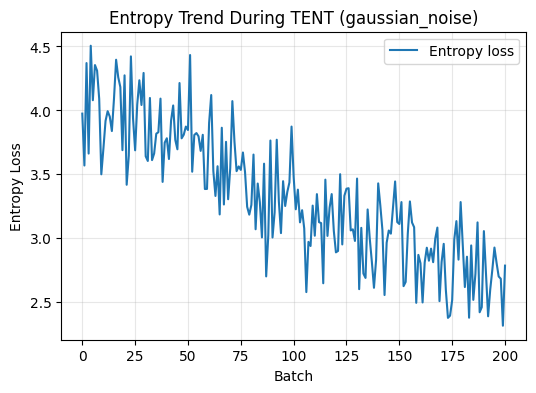

Baseline: 47.36  TENT: 44.53


In [46]:
corruption1 = "gaussian_noise"
base1, tent1, ents1 = imagenet_eval(corruption1, severity=3, steps=201)

plot_entropy_curve(ents1, corruption1)
print(f"Baseline: {base1:.2f}  TENT: {tent1:.2f}")


=== ImageNet-C Experiment: motion_blur (severity 3) ===


Evaluating on Baseline (motion_blur):   2%|▏         | 16/782 [01:19<1:03:21,  4.96s/it]


[TENT] Step 0: entropy=3.6078
[TENT] Step 20: entropy=3.2014
[TENT] Step 40: entropy=2.8854
[TENT] Step 60: entropy=2.6519
[TENT] Step 80: entropy=2.5602
[TENT] Step 100: entropy=1.6564
[TENT] Step 120: entropy=1.9209
[TENT] Step 140: entropy=2.0201
[TENT] Step 160: entropy=2.1249
[TENT] Step 180: entropy=1.6135
[TENT] Step 200: entropy=2.7455


Evaluating on TENT Final (motion_blur):   2%|▏         | 16/782 [01:15<1:00:23,  4.73s/it]


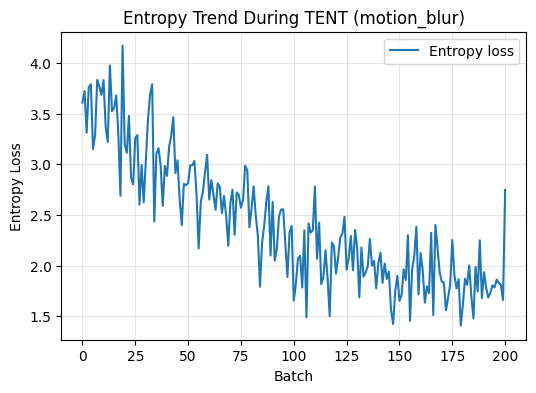

Baseline: 31.64  TENT: 52.05


In [ ]:
corruption2 = "motion_blur"
base2, tent2, ents2 = imagenet_eval(corruption2, severity=3, steps=201)

plot_entropy_curve(ents2, corruption2)
print(f"Baseline: {base2:.2f}  TENT: {tent2:.2f}")

# ran in 42 mins


=== ImageNet-C Experiment: defocus_blur (severity 3) ===


Evaluating on Baseline (defocus_blur):   2%|▏         | 16/782 [01:12<57:40,  4.52s/it]


[TENT] Step 0: entropy=4.3460
[TENT] Step 20: entropy=4.3181
[TENT] Step 40: entropy=4.0324
[TENT] Step 60: entropy=3.6760
[TENT] Step 80: entropy=3.9341
[TENT] Step 100: entropy=2.9463
[TENT] Step 120: entropy=3.2641
[TENT] Step 140: entropy=3.2771
[TENT] Step 160: entropy=3.1143
[TENT] Step 180: entropy=2.4973
[TENT] Step 200: entropy=2.5925


Evaluating on TENT Final (defocus_blur):   2%|▏         | 16/782 [01:09<55:21,  4.34s/it]


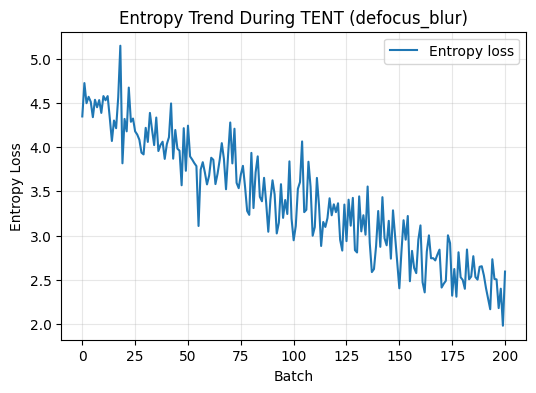

Baseline: 23.73  TENT: 32.42


In [47]:
corruption3 = "defocus_blur"
base3, tent3, ents3 = imagenet_eval(corruption3, severity=3, steps=201)

plot_entropy_curve(ents3, corruption3)
print(f"Baseline: {base3:.2f}  TENT: {tent3:.2f}")


=== ImageNet-C Experiment: brightness (severity 3) ===


Evaluating on Baseline (brightness):   2%|▏         | 16/782 [01:11<56:56,  4.46s/it]


[TENT] Step 0: entropy=1.1852
[TENT] Step 20: entropy=0.8774
[TENT] Step 40: entropy=0.7144
[TENT] Step 60: entropy=0.6764
[TENT] Step 80: entropy=1.0848
[TENT] Step 100: entropy=0.7380
[TENT] Step 120: entropy=0.7680
[TENT] Step 140: entropy=0.5773
[TENT] Step 160: entropy=0.4849
[TENT] Step 180: entropy=0.8037
[TENT] Step 200: entropy=0.6148


Evaluating on TENT Final (brightness):   2%|▏         | 16/782 [01:08<54:46,  4.29s/it]


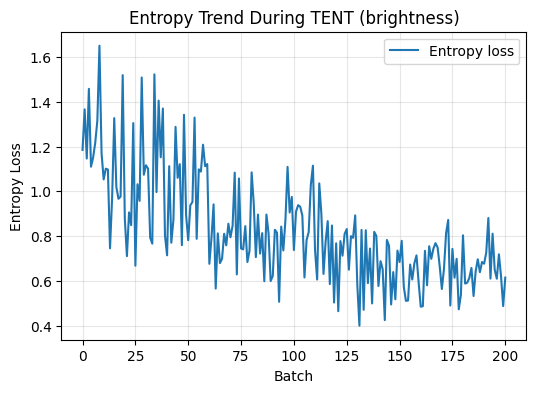

Baseline: 70.31  TENT: 75.68


In [48]:
corruption4 = "brightness"
base4, tent4, ents4 = imagenet_eval(corruption4, severity=3, steps=201)

plot_entropy_curve(ents4, corruption4)
print(f"Baseline: {base4:.2f}  TENT: {tent4:.2f}")


=== ImageNet-C Experiment: fog (severity 3) ===


Evaluating on Baseline (fog):   2%|▏         | 16/782 [01:10<56:29,  4.43s/it]


[TENT] Step 0: entropy=2.3502
[TENT] Step 20: entropy=2.5545
[TENT] Step 40: entropy=1.8494
[TENT] Step 60: entropy=1.6335
[TENT] Step 80: entropy=1.6217
[TENT] Step 100: entropy=1.5083
[TENT] Step 120: entropy=1.6124
[TENT] Step 140: entropy=1.2886
[TENT] Step 160: entropy=1.3323
[TENT] Step 180: entropy=0.9455
[TENT] Step 200: entropy=1.1450


Evaluating on TENT Final (fog):   2%|▏         | 16/782 [01:07<54:08,  4.24s/it]


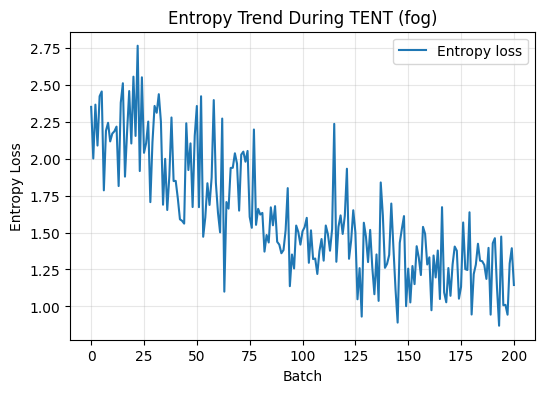

Baseline: 37.60  TENT: 64.45


In [49]:
corruption5 = "fog"
base5, tent5, ents5 = imagenet_eval(corruption5, severity=3, steps=201)

plot_entropy_curve(ents5, corruption5)
print(f"Baseline: {base5:.2f}  TENT: {tent5:.2f}")